# Titanic Environment Test
Verifying Jupyter kernel and environment setup

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import train_test_split , GridSearchCV




In [83]:
train_df=pd.read_csv("train.csv")
test_df=pd.read_csv("test.csv")
train_df.head(len(train_df.columns))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [84]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [85]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [86]:
train_df.describe(include="O")

C:\Users\student\AppData\Local\Temp\ipykernel_7676\1170404951.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train_df.describe(include="O")


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [87]:
train_df.groupby('Pclass', as_index=False)['Survived'].mean().sort_values(by='Survived', ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [88]:
train_df.groupby('Age',as_index=False)['Survived'].mean().sort_values(by='Survived', ascending=False)

,Age,Survived
0,0.42,1.0
1,0.67,1.0
2,0.75,1.0
3,0.83,1.0
4,0.92,1.0
...,...,...
81,65.00,0.0
83,70.00,0.0
84,70.50,0.0
85,71.00,0.0


In [89]:
train_df.groupby('Sex' , as_index=False)['Survived'].mean().sort_values(by='Survived', ascending=False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [90]:
train_df.groupby('Parch', as_index=False)['Survived'].mean().sort_values(by='Survived', ascending=False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


In [91]:
train_df.groupby('SibSp', as_index=False)['Survived'].mean().sort_values(by='Survived', ascending=False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [92]:
#creating a new column called family size by adding the number of siblings/spouses and parents/children together to see if it has any effect on survival rate. .
train_df['FamilySize']=train_df['SibSp']+train_df['Parch']
test_df['FamilySize']=test_df['SibSp']+test_df['Parch']
train_df.groupby('FamilySize', as_index=False)['Survived'].mean().sort_values(by='Survived', ascending=False)

,FamilySize,Survived
3,3,0.724138
2,2,0.578431
1,1,0.552795
6,6,0.333333
0,0,0.303538
4,4,0.200000
5,5,0.136364
7,7,0.000000
8,10,0.000000


In [93]:
train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,0
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,0
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,4
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,2
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,1


In [94]:
#this is a map to categorize family size into groups for better analysis of survival rates based on family size.
family_map={0:'Alone', 1:'Alone', 2:'Small', 3:'Small', 4:'Medium', 5:'Medium', 6:'Medium', 7:'Large', 8:'Large  ', 9:'Large', 10:'Large',}

In [95]:
train_df['FamilySizeGroup']=train_df['FamilySize'].map(family_map)
test_df['FamilySizeGroup']=test_df['FamilySize'].map(family_map)

In [96]:
train_df.groupby('FamilySizeGroup', as_index=False)['Survived'].mean().sort_values(by='Survived', ascending=False)

,FamilySizeGroup,Survived
3,Small,0.610687
0,Alone,0.361032
2,Medium,0.204082
1,Large,0.000000


In [97]:
train_df.groupby('Embarked', as_index=False)['Survived'].mean().sort_values(by='Survived', ascending=False)

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.336957


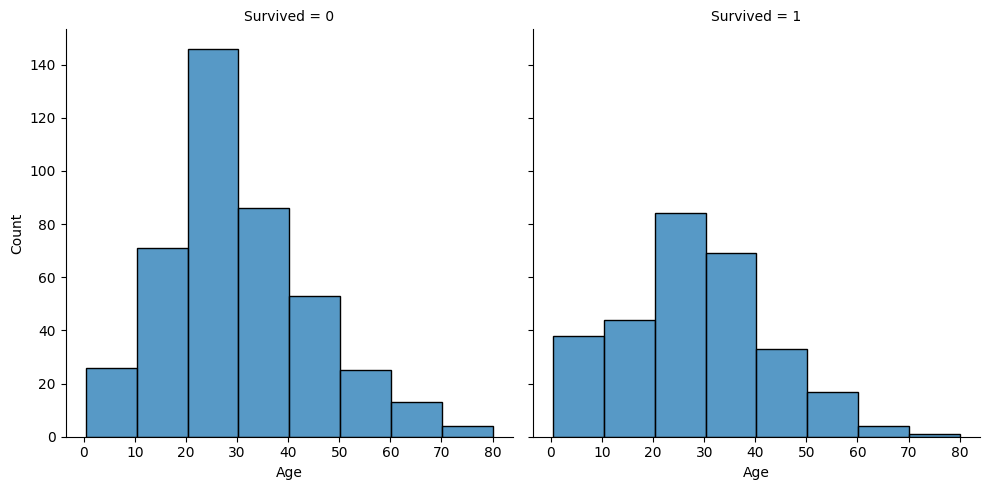

In [98]:
sns.displot(train_df, x='Age', col="Survived", binwidth=10, height=5)

In [99]:
#here we are categorizing age into 8  EQUAL groups to see if it has any effect on survival rate. and because age is a continuous variable, categorizing it into groups can help us analyze the relationship between age and survival more effectively. By using pd.qcut, we can create quantile-based bins that ensure each group has an equal number of observations, which can provide insights into how different age groups fared in terms of survival rates.
train_df["Age_cut"]=pd.qcut(train_df['Age'], 8)
test_df["Age_cut"]=pd.qcut(test_df['Age'], 8)

In [100]:
train_df.groupby('Age_cut', as_index=False)['Survived'].mean().sort_values(by='Age_cut', ascending=True)

,Age_cut,Survived
0,"(0.419, 16.0]",0.550000
1,"(16.0, 20.125]",0.341772
2,"(20.125, 24.0]",0.367347
3,"(24.0, 28.0]",0.352941
4,"(28.0, 32.312]",0.416667
5,"(32.312, 38.0]",0.450549
6,"(38.0, 47.0]",0.329545
7,"(47.0, 80.0]",0.415730


In [101]:
#next we base the 8 equal groups into  ranges of ages for better modeling and analysis of survival rates based on age groups.
train_df.loc[train_df['Age']<=16, "Age"]=0
train_df.loc[(train_df['Age']>16) & (train_df['Age']<=20), 'Age']=1
train_df.loc[(train_df['Age']>20) & (train_df['Age']<=24), 'Age']=2
train_df.loc[(train_df['Age']>24) & (train_df['Age']<=28), 'Age']=3
train_df.loc[(train_df['Age']>28) & (train_df['Age']<=32), 'Age']=4
train_df.loc[(train_df['Age']>32) & (train_df['Age']<=38), 'Age']=5
train_df.loc[(train_df['Age']>38) & (train_df['Age']<=47), 'Age']=6
train_df.loc[(train_df['Age']>47) & (train_df['Age']<=80), 'Age']=7


test_df.loc[test_df['Age']<=16, "Age"]=0
test_df.loc[(test_df['Age']>16) & (test_df['Age']<=20), 'Age']=1
test_df.loc[(test_df['Age']>20) & (test_df['Age']<=24), 'Age']=2
test_df.loc[(test_df['Age']>24) & (test_df['Age']<=28), 'Age']=3
test_df.loc[(test_df['Age']>28) & (test_df['Age']<=32), 'Age']=4
test_df.loc[(test_df['Age']>32) & (test_df['Age']<=38), 'Age']=5
test_df.loc[(test_df['Age']>38) & (test_df['Age']<=47), 'Age']=6
test_df.loc[(test_df['Age']>47) & (test_df['Age']<=80), 'Age']=7

In [102]:
train_df.head(100)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,FamilySizeGroup,Age_cut
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,7.2500,NaN,S,1,Alone,"(20.125, 24.0]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,71.2833,C85,C,1,Alone,"(32.312, 38.0]"
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,Alone,"(24.0, 28.0]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,53.1000,C123,S,1,Alone,"(32.312, 38.0]"
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,8.0500,NaN,S,0,Alone,"(32.312, 38.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0,3,"Shorney, Mr. Charles Joseph",male,NaN,0,0,374910,8.0500,NaN,S,0,Alone,NaN
96,97,0,1,"Goldschmidt, Mr. George B",male,7.0,0,0,PC 17754,34.6542,A5,C,0,Alone,"(47.0, 80.0]"
97,98,1,1,"Greenfield, Mr. William Bertram",male,2.0,0,1,PC 17759,63.3583,D10 D12,C,1,Alone,"(20.125, 24.0]"
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,5.0,0,1,231919,23.0000,NaN,S,1,Alone,"(32.312, 38.0]"


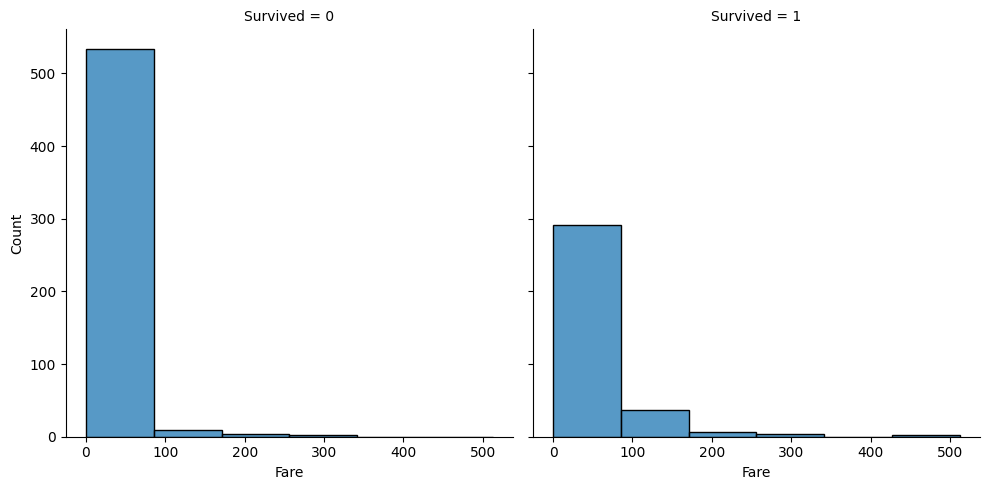

In [103]:
sns.displot(train_df, x="Fare", col="Survived", binwidth=80, height=5)

In [104]:
train_df['Fare_cut']=pd.qcut(train_df['Fare'], q=6)
test_df['Fare_cut']=pd.qcut(test_df['Fare'], q=6)

In [105]:
train_df.groupby('Fare_cut', as_index=False)['Survived'].mean().sort_values(by='Fare_cut', ascending=True)

,Fare_cut,Survived
0,"(-0.001, 7.775]",0.205128
1,"(7.775, 8.662]",0.190789
2,"(8.662, 14.454]",0.366906
3,"(14.454, 26.0]",0.436242
4,"(26.0, 52.369]",0.417808
5,"(52.369, 512.329]",0.697987


In [106]:
train_df.loc[train_df['Fare']<=7.775, 'Fare']=0 
train_df.loc[(train_df['Fare']>7.775) & (train_df['Fare']<=8.662), 'Fare']=1
train_df.loc[(train_df['Fare']>8.662) & (train_df['Fare']<=14.454), 'Fare']=2
train_df.loc[(train_df['Fare']>14.454) & (train_df['Fare']<=26.0), 'Fare']=3
train_df.loc[(train_df['Fare']>26.0) & (train_df['Fare']<=52.0), 'Fare']=4
train_df.loc[(train_df['Fare']>52.0) & (train_df['Fare']<=512.3292), 'Fare']=5

test_df.loc[test_df['Fare']<=7.775, 'Fare']=0
test_df.loc[(test_df['Fare']>7.775) & (test_df['Fare']<=14.454), 'Fare']=2
test_df.loc[(test_df['Fare']>14.454) & (test_df['Fare']<=26.0), 'Fare']=3
test_df.loc[(test_df['Fare']>26.0) & (test_df['Fare']<=52.0), 'Fare']=4
test_df.loc[(test_df['Fare']>52.0) & (test_df['Fare']<=512.3292), 'Fare']=5  


In [107]:
train_df.head(100)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,FamilySizeGroup,Age_cut,Fare_cut
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,0.0,NaN,S,1,Alone,"(20.125, 24.0]","(-0.001, 7.775]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,5.0,C85,C,1,Alone,"(32.312, 38.0]","(52.369, 512.329]"
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,1.0,NaN,S,0,Alone,"(24.0, 28.0]","(7.775, 8.662]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,5.0,C123,S,1,Alone,"(32.312, 38.0]","(52.369, 512.329]"
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,1.0,NaN,S,0,Alone,"(32.312, 38.0]","(7.775, 8.662]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0,3,"Shorney, Mr. Charles Joseph",male,NaN,0,0,374910,1.0,NaN,S,0,Alone,NaN,"(7.775, 8.662]"
96,97,0,1,"Goldschmidt, Mr. George B",male,7.0,0,0,PC 17754,4.0,A5,C,0,Alone,"(47.0, 80.0]","(26.0, 52.369]"
97,98,1,1,"Greenfield, Mr. William Bertram",male,2.0,0,1,PC 17759,5.0,D10 D12,C,1,Alone,"(20.125, 24.0]","(52.369, 512.329]"
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,5.0,0,1,231919,3.0,NaN,S,1,Alone,"(32.312, 38.0]","(14.454, 26.0]"


In [108]:
#hERE we are splitting the name column into two columns based on the pattern of the comma.
train_df['Name'].str.split(pat=',', expand=True)[1]

0                                  Mr. Owen Harris
1       Mrs. John Bradley (Florence Briggs Thayer)
2                                      Miss. Laina
3               Mrs. Jacques Heath (Lily May Peel)
4                                Mr. William Henry
                          ...                     
886                                    Rev. Juozas
887                           Miss. Margaret Edith
888                 Miss. Catherine Helen "Carrie"
889                                Mr. Karl Howell
890                                    Mr. Patrick
Name: 1, Length: 891, dtype: str

In [109]:
train_df['Title']=train_df['Name'].str.split(pat=',', expand=True)[1].str.split(pat='.', expand=True)[0].apply(lambda x: x.strip())
test_df['Title']=test_df['Name'].str.split(pat=',', expand=True)[1].str.split(pat='.', expand=True)[0].apply(lambda x: x.strip())

In [110]:
train_df.head(100)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,FamilySizeGroup,Age_cut,Fare_cut,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,0.0,NaN,S,1,Alone,"(20.125, 24.0]","(-0.001, 7.775]",Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,5.0,C85,C,1,Alone,"(32.312, 38.0]","(52.369, 512.329]",Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,1.0,NaN,S,0,Alone,"(24.0, 28.0]","(7.775, 8.662]",Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,5.0,C123,S,1,Alone,"(32.312, 38.0]","(52.369, 512.329]",Mrs
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,1.0,NaN,S,0,Alone,"(32.312, 38.0]","(7.775, 8.662]",Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0,3,"Shorney, Mr. Charles Joseph",male,NaN,0,0,374910,1.0,NaN,S,0,Alone,NaN,"(7.775, 8.662]",Mr
96,97,0,1,"Goldschmidt, Mr. George B",male,7.0,0,0,PC 17754,4.0,A5,C,0,Alone,"(47.0, 80.0]","(26.0, 52.369]",Mr
97,98,1,1,"Greenfield, Mr. William Bertram",male,2.0,0,1,PC 17759,5.0,D10 D12,C,1,Alone,"(20.125, 24.0]","(52.369, 512.329]",Mr
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,5.0,0,1,231919,3.0,NaN,S,1,Alone,"(32.312, 38.0]","(14.454, 26.0]",Mrs


In [111]:
train_df.groupby('Title', as_index=False)['Survived'].mean()

,Title,Survived
0,Capt,0.000000
1,Col,0.500000
2,Don,0.000000
3,Dr,0.428571
4,Jonkheer,0.000000
5,Lady,1.000000
6,Major,0.500000
7,Master,0.575000
8,Miss,0.697802
9,Mlle,1.000000


In [112]:
#military = capt,col, major, don,master
#royalty = the countess, lady, sir, jonkheer
#unmarried females = miss, mlle, mme

In [113]:
train_df['Title']=train_df['Title'].replace({
    'Capt': 'Military',
    'Col': 'Military',
    'Major': 'Military',
    'Don': 'Military',
    'Master': 'Military',
    'the Countess': 'Royalty',
    'Lady': 'Royalty',
    'Sir': 'Royalty',
    'Jonkheer': 'Royalty',
    'Miss': 'Unmarried',
    'Mlle': 'Unmarried',
    'Mme': 'Unmarried',
})
test_df['Title']=test_df['Title'].replace({
    'Capt': 'Military',
    'Col': 'Military',
    'Major': 'Military',
    'Don': 'Military',
    'Master': 'Military',
    'the Countess': 'Royalty',
    'Lady': 'Royalty',
    'Sir': 'Royalty',
    'Jonkheer': 'Royalty',
    'Miss': 'Unmarried',
    'Mlle': 'Unmarried',
    'Mme': 'Unmarried',
})



In [114]:
train_df.head(100)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,FamilySizeGroup,Age_cut,Fare_cut,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,0.0,NaN,S,1,Alone,"(20.125, 24.0]","(-0.001, 7.775]",Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,5.0,C85,C,1,Alone,"(32.312, 38.0]","(52.369, 512.329]",Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,1.0,NaN,S,0,Alone,"(24.0, 28.0]","(7.775, 8.662]",Unmarried
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,5.0,C123,S,1,Alone,"(32.312, 38.0]","(52.369, 512.329]",Mrs
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,1.0,NaN,S,0,Alone,"(32.312, 38.0]","(7.775, 8.662]",Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0,3,"Shorney, Mr. Charles Joseph",male,NaN,0,0,374910,1.0,NaN,S,0,Alone,NaN,"(7.775, 8.662]",Mr
96,97,0,1,"Goldschmidt, Mr. George B",male,7.0,0,0,PC 17754,4.0,A5,C,0,Alone,"(47.0, 80.0]","(26.0, 52.369]",Mr
97,98,1,1,"Greenfield, Mr. William Bertram",male,2.0,0,1,PC 17759,5.0,D10 D12,C,1,Alone,"(20.125, 24.0]","(52.369, 512.329]",Mr
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,5.0,0,1,231919,3.0,NaN,S,1,Alone,"(32.312, 38.0]","(14.454, 26.0]",Mrs


In [115]:
train_df.groupby('Title', as_index=False)['Survived'].agg(['count', 'mean'])

,Title,count,mean
0,Dr,7,0.428571
1,Military,46,0.543478
2,Mr,517,0.156673
3,Mrs,125,0.792000
4,Ms,1,1.000000
5,Rev,6,0.000000
6,Royalty,4,0.750000
7,Unmarried,185,0.702703


In [117]:
train_df['Name_length']=train_df['Name'].apply(lambda x : len(x))